In [70]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json, os, math
import joblib
from tqdm import tqdm
import torch
from NeuralSelector.index import NeuralSelector

# CONFIGURAÇÕES

In [71]:
OPTIONS = json.loads(open('info.json', 'r').read())
dt      = OPTIONS.get('dt')

x_min, x_max = OPTIONS.get('sensor_range')
u_min, u_max = OPTIONS.get('actuator_range')
OFFSET = OPTIONS.get('offset')
ts     = OPTIONS.get('ts')
u_std  = OPTIONS.get('actuator_std')

- Loading System Simulator

In [72]:
system_info  = json.loads(open('Saved/System/info.json', 'r').read())
system_vars  = system_info['variables']
n_states_sys = sum(['x(n-' in var for var in system_vars]) + 1
n_states_ctl = sum(['u(n-' in var for var in system_vars]) + 1

print(system_info)
print(system_vars)
print(n_states_sys, 'system past states')
print(n_states_ctl, 'actuator past states')

system = joblib.load('Saved/System/model.pkl')
system

{'model': 'linear_regression', 'params': {'memory': 'None', 'steps': "[('scaler', StandardScaler()), ('model', LinearRegression())]", 'transform_input': 'None', 'verbose': 'False', 'scaler': 'StandardScaler()', 'model': 'LinearRegression()', 'scaler__copy': 'True', 'scaler__with_mean': 'True', 'scaler__with_std': 'True', 'model__copy_X': 'True', 'model__fit_intercept': 'True', 'model__n_jobs': 'None', 'model__positive': 'False', 'model__tol': '1e-06'}, 'K_CV': 5, 'info': {'r2': 0.9962738131, 'r2_adj': 0.9961557689, 'rmse': 0.0043166528, 'mae': 0.0016836612}, 'variables': ['u', 'u(n-1)', 'u(n-2)', 'u(n-3)', 'u(n-4)', 'u(n-5)', 'u(n-6)', 'u(n-7)', 'u(n-8)', 'u(n-9)', 'u(n-10)', 'u(n-11)', 'u(n-12)', 'u(n-13)', 'u(n-14)', 'u(n-15)', 'u(n-16)', 'u(n-17)', 'u(n-18)', 'u(n-19)', 'u(n-20)', 'u(n-21)', 'u(n-22)', 'u(n-23)', 'u(n-24)', 'u(n-25)', 'u(n-26)', 'x(n-1)', 'x(n-2)', 'x(n-3)', 'x(n-4)', 'x(n-5)', 'x(n-6)', 'x(n-7)', 'x(n-8)', 'x(n-9)', 'x(n-10)', 'x(n-11)', 'x(n-12)', 'x(n-13)', 'x(n-

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [73]:
control_info = json.load(open('Saved/Controller/info.json', 'r'))

selector = NeuralSelector(control_info['architecture'])
Actor, Evaluator, params = selector.get()

actor_kwargs = control_info['actor_kwargs']
max_action = control_info.get('max_action', 50.0)

state_dim = (2 + n_states_sys + n_states_ctl) # Calcula o tamanho exato da camada de entrada automaticamente!

actor = Actor(state_dim=state_dim, action_dim=1, max_action=max_action, **actor_kwargs)
actor.load_state_dict(torch.load('Saved/Controller/actor.pth'))
actor.eval() # Muito importante manter o eval() ligado para inferência!

DynamicLstmActor(
  (lstm): LSTM(56, 128, batch_first=True)
  (outLayer): Linear(in_features=128, out_features=1, bias=True)
)

# SIMULADOR
- Simulador Matemático do Sistema (Plant). Reage aos comandos do atuador 
    e devolve a nova leitura do sensor, embasado no modelo empírico de regressão.

In [74]:
class StatesUpdater:
    def __init__(self, size, initial=0.00):
        self.initial = initial
        self.size = size
        self.buffer = np.array([initial for _ in range(size)])
        
    def update(self, value):
        for i in range(self.size-1, 0, -1):
            self.buffer[i] = self.buffer[i-1]
        self.buffer[0] = value
        return self.buffer
    
    def get(self, var='x'):
        data = {var: self.buffer[0]}
        for i in range(1, self.size):
            data[f'{var}(n-{i})'] = self.buffer[i]
        return {key: float(val) for key, val in data.items()}

In [75]:
class System:
    def __init__(self, model, columns, n_states_sys, n_states_ctl, init_x=0.0, init_u=0.0):
        self.n_states_sys = n_states_sys
        self.n_states_ctl = n_states_ctl
        
        self.sensor   = StatesUpdater(self.n_states_sys, initial=init_x)
        self.actuator = StatesUpdater(self.n_states_ctl, initial=init_u)
        
        self.model = model
        self.cols  = columns

    def update(self, actuator_val):
        self.actuator.update(actuator_val)
        data = self.actuator.get('u')
        
        for i in range(1, self.n_states_sys):
            data[f'x(n-{i})'] = self.sensor.buffer[i-1]
            
        response = self.model.predict(pd.DataFrame([data], columns=self.cols))[0]
        self.sensor.update(response)
        return self.sensor.buffer[0]

# CONTROLADOR

In [76]:
class Controller:
    def __init__(self, actor_model, n_states_sys, n_states_ctl, init_x=0.0, init_u=0.0):
        self.n_states_sys = n_states_sys
        self.n_states_ctl = n_states_ctl

        self.integral_err = 0.0
        self.integral_clip = ((x_max - x_min) / 2.0) * ts
        self.prev_delta_u = 0.0
        
        self.sensor   = StatesUpdater(self.n_states_sys, initial=init_x)
        self.actuator = StatesUpdater(self.n_states_ctl, initial=init_u)
        self.actor_model = actor_model
        
    def update(self, setpoint, sensor_val):
        self.sensor.update(sensor_val)
        
        sensor_center    = (x_max + x_min) / 2.0
        sensor_amplitude = (x_max - x_min) / 2.0
        
        actuator_center    = (u_max + u_min) / 2.0
        actuator_amplitude = (u_max - u_min) / 2.0
        
        error = setpoint - self.sensor.buffer[0]
        normalized_error = error / sensor_amplitude
        
        integral_norm = np.clip(self.integral_err / self.integral_clip, -1.0, 1.0)
        state = [normalized_error, integral_norm]   # ERA: state = [normalized_error]
        
        for i in range(self.n_states_sys):
            normalized_x = (self.sensor.buffer[i] - sensor_center) / sensor_amplitude
            state.append(normalized_x)
            
        for i in range(self.n_states_ctl):
            normalized_u = (self.actuator.buffer[i] - actuator_center) / actuator_amplitude
            state.append(normalized_u)
            
        state_tensor = torch.FloatTensor(np.array(state, dtype=np.float32).reshape(1, -1))
        
        with torch.no_grad():
            delta_u = self.actor_model(state_tensor).cpu().data.numpy().flatten()[0]
            
        # Calcula a nova ação e já clipa nos limites físicos (ex: 45 a 135)
        response = self.actuator.buffer[0] + delta_u
        response = np.clip(response, u_min, u_max)
        
        self.actuator.update(response)
        return response

## FEEDBACK (MALHA FECHADA)
Injetamos uma série sintética de variações dinâmicas de setpoint para testar a capacidade da rede de manter a trajetória suavemente.

In [77]:
STEP = int(10*ts/dt)
setpoints = [0.12] * STEP + [0.15] * STEP + [0.10] * STEP + [0.05] * STEP + [0.15] * STEP
init_x = (x_max + x_min) / 2.0
init_u = (u_max + u_min) / 2.0

system     = System(system, system_vars, n_states_sys, n_states_ctl, init_x=init_x, init_u=init_u)
controller = Controller(actor, n_states_sys, n_states_ctl, init_x=init_x, init_u=init_u)

results = []
sensor_val = init_x
time = 0

for sp in tqdm(setpoints):
    actuator_val = controller.update(sp, sensor_val)
    sensor_val   = system.update(actuator_val)
    
    time = (time + dt)
    results.append({'t': time, 'setpoint': sp, 'x': sensor_val, 'u': actuator_val, 'error': sp - sensor_val})

df = pd.DataFrame(results)
df

100%|██████████| 8040/8040 [00:10<00:00, 795.54it/s]


,t,setpoint,x,u,error
0,0.048,0.12,0.149295,81.949139,-0.029295
1,0.096,0.12,0.148370,73.548241,-0.028370
2,0.144,0.12,0.147559,65.508188,-0.027559
3,0.192,0.12,0.147900,58.400968,-0.027900
4,0.240,0.12,0.150776,52.940508,-0.030776
...,...,...,...,...,...
8035,385.728,0.15,0.172992,79.260692,-0.022992
8036,385.776,0.15,0.166472,75.650748,-0.016472
8037,385.824,0.15,0.158929,69.954491,-0.008929
8038,385.872,0.15,0.151069,63.339301,-0.001069


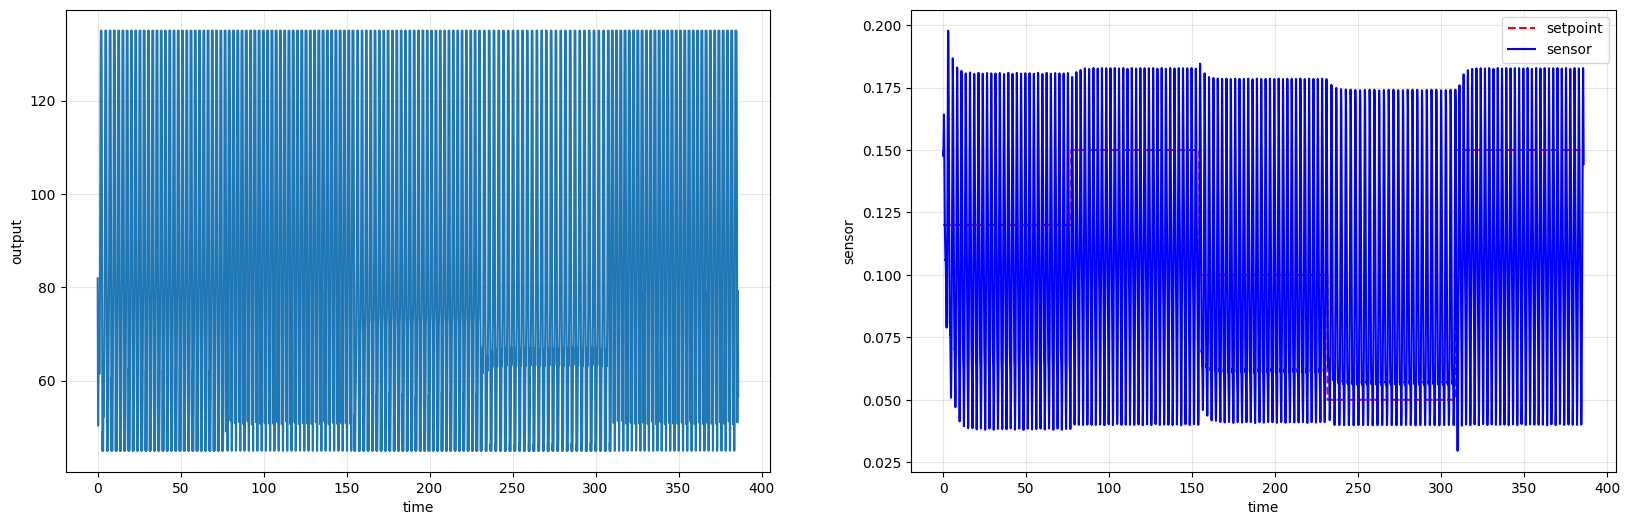

In [78]:
plt.figure(figsize=(20, 6))
plt.subplot(1, 2, 1)
plt.plot(df.t, df.u, label='output')
plt.ylabel('output'); plt.xlabel('time'); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(df.t, df.setpoint, 'r--', label='setpoint')
plt.plot(df.t, df.x, 'b-', label='sensor')
plt.xlabel('time'); plt.ylabel('sensor'); plt.legend(); plt.grid(alpha=0.3)
plt.show()